# Smoke Segmentation Model - SMOKE5K Dataset

This notebook trains a simple U-Net model for binary smoke segmentation using the SMOKE5K dataset with ~5,000 labeled images.

In [1]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.transforms.functional as TF

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cpu


In [2]:
# Set Up Data Paths
smoke5k_img_path = "dataset/smoke5k/train/img"
smoke5k_gt_path = "dataset/smoke5k/train/gt"

# Get all image files
all_images = sorted([f for f in os.listdir(smoke5k_img_path) if f.endswith(('.jpg', '.png'))])
print(f"Total images found: {len(all_images)}")

# Use a subset for faster training (adjust as needed)
MAX_SAMPLES = 500  # Use first 1000 images for quick training
all_images = all_images[:MAX_SAMPLES]
print(f"Using {len(all_images)} images for training")

Total images found: 5058
Using 500 images for training


In [3]:
# Custom Dataset Class
class Smoke5kDataset(Dataset):
    def __init__(self, image_list, img_dir, gt_dir, img_size=256, transform=None):
        self.image_list = image_list
        self.img_dir = img_dir
        self.gt_dir = gt_dir
        self.img_size = img_size
        self.transform = transform
        
    def __len__(self):
        return len(self.image_list)
    
    def __getitem__(self, idx):
        img_name = self.image_list[idx]
        
        # Load image
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        # Load mask (change extension to .png if needed)
        mask_name = img_name.replace('.jpg', '.png')
        mask_path = os.path.join(self.gt_dir, mask_name)
        mask = Image.open(mask_path).convert('L')
        
        # Resize
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        
        # Convert to tensors
        image = TF.to_tensor(image)  # [0, 1] range, shape [3, H, W]
        mask = torch.from_numpy(np.array(mask)).float() / 255.0  # [0, 1] range
        mask = mask.unsqueeze(0)  # shape [1, H, W]
        
        # Normalize image
        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        
        return image, mask

# Test the dataset
test_dataset = Smoke5kDataset(all_images[:5], smoke5k_img_path, smoke5k_gt_path)
sample_img, sample_mask = test_dataset[0]
print(f"Image shape: {sample_img.shape}, Mask shape: {sample_mask.shape}")
print(f"Image range: [{sample_img.min():.2f}, {sample_img.max():.2f}]")
print(f"Mask unique values: {torch.unique(sample_mask)}")

Image shape: torch.Size([3, 256, 256]), Mask shape: torch.Size([1, 256, 256])
Image range: [-2.07, 2.64]
Mask unique values: tensor([0., 1.])


In [4]:
# Create Data Loaders
IMG_SIZE = 256
BATCH_SIZE = 8
VAL_SPLIT = 0.2

# Create full dataset
full_dataset = Smoke5kDataset(all_images, smoke5k_img_path, smoke5k_gt_path, img_size=IMG_SIZE)

# Split into train and validation
val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

Training samples: 400
Validation samples: 100
Batches per epoch: 50


In [6]:
# Simple U-Net Model
class DoubleConv(nn.Module):
    """Two consecutive conv layers with BatchNorm and ReLU"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        
        # Encoder (downsampling)
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        
        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)
        
        # Decoder (upsampling)
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        
        # Output layer
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)
        
        self.pool = nn.MaxPool2d(2)
    
    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        
        # Bottleneck
        b = self.bottleneck(self.pool(e4))
        
        # Decoder with skip connections
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
        
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        
        return self.out_conv(d1)

# Create model
model = SimpleUNet(in_channels=3, out_channels=1).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model created with {total_params:,} parameters")

Model created with 31,043,521 parameters


In [7]:
# Training Configuration
LEARNING_RATE = 1e-4
NUM_EPOCHS = 5

# Loss function and optimizer
criterion = nn.BCEWithLogitsLoss()  # Binary cross-entropy with sigmoid built-in
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print(f"Training configuration:")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Epochs: {NUM_EPOCHS}")
print(f"  - Loss: BCEWithLogitsLoss")
print(f"  - Optimizer: Adam")

Training configuration:
  - Learning rate: 0.0001
  - Epochs: 5
  - Loss: BCEWithLogitsLoss
  - Optimizer: Adam


In [ ]:
# Helper functions for metrics
def calculate_iou(pred, target, threshold=0.5):
    """Calculate Intersection over Union"""
    pred_binary = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_binary * target).sum()
    union = pred_binary.sum() + target.sum() - intersection
    return (intersection / (union + 1e-8)).item()

def calculate_dice(pred, target, threshold=0.5):
    """Calculate Dice coefficient"""
    pred_binary = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_binary * target).sum()
    return (2 * intersection / (pred_binary.sum() + target.sum() + 1e-8)).item()

# Training loop
train_losses = []
val_losses = []
val_ious = []

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    epoch_train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0
    epoch_iou = 0
    
    with torch.no_grad():
        for images, masks in val_loader:
            print(f"Validation batch - Images shape: {images.shape}, Masks shape: {masks.shape}")
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            epoch_val_loss += loss.item()
            epoch_iou += calculate_iou(outputs, masks)
    
    avg_val_loss = epoch_val_loss / len(val_loader)
    avg_iou = epoch_iou / len(val_loader)
    val_losses.append(avg_val_loss)
    val_ious.append(avg_iou)
    
    # Update learning rate
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, IoU={avg_iou:.4f}")

print("\nTraining complete!")

Starting training...


Epoch 1/5:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/5: 100%|██████████| 50/50 [13:34<00:00, 16.29s/it, loss=0.3155]


Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256,

Epoch 2/5: 100%|██████████| 50/50 [10:01<00:00, 12.02s/it, loss=0.2442]


Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256,

Epoch 3/5: 100%|██████████| 50/50 [10:51<00:00, 13.02s/it, loss=0.3277]


Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])
Validation batch - Images shape: torch.Size([8, 3, 256,

Epoch 4/5:  86%|████████▌ | 43/50 [16:02<02:23, 20.54s/it, loss=0.2944]

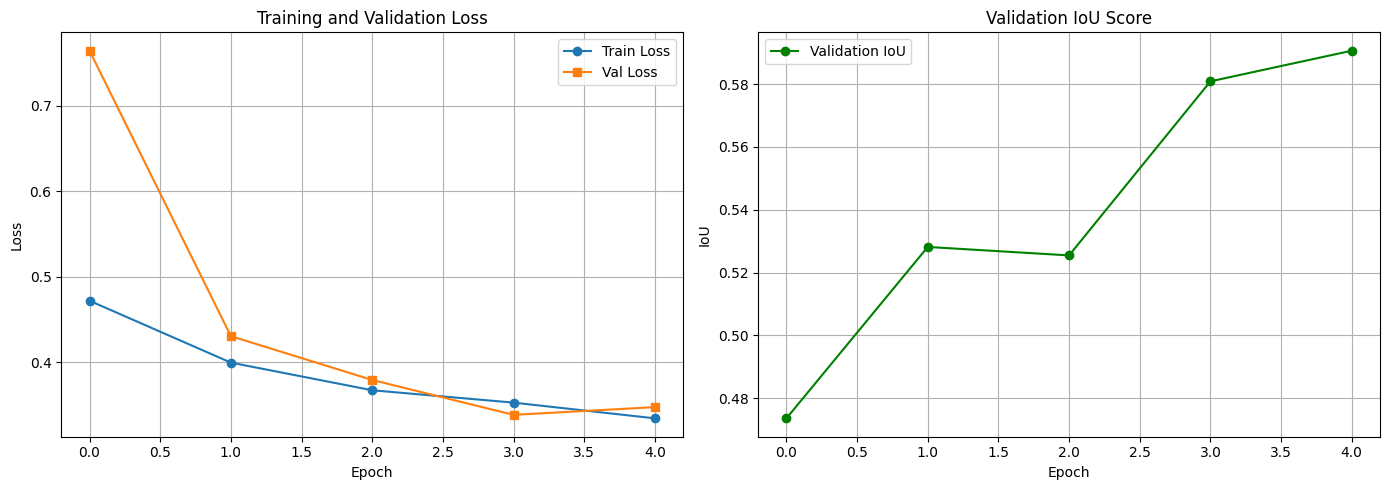

Best Validation IoU: 0.5907 at epoch 5


In [9]:
# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# IoU plot
axes[1].plot(val_ious, label='Validation IoU', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].set_title('Validation IoU Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Best Validation IoU: {max(val_ious):.4f} at epoch {val_ious.index(max(val_ious)) + 1}")

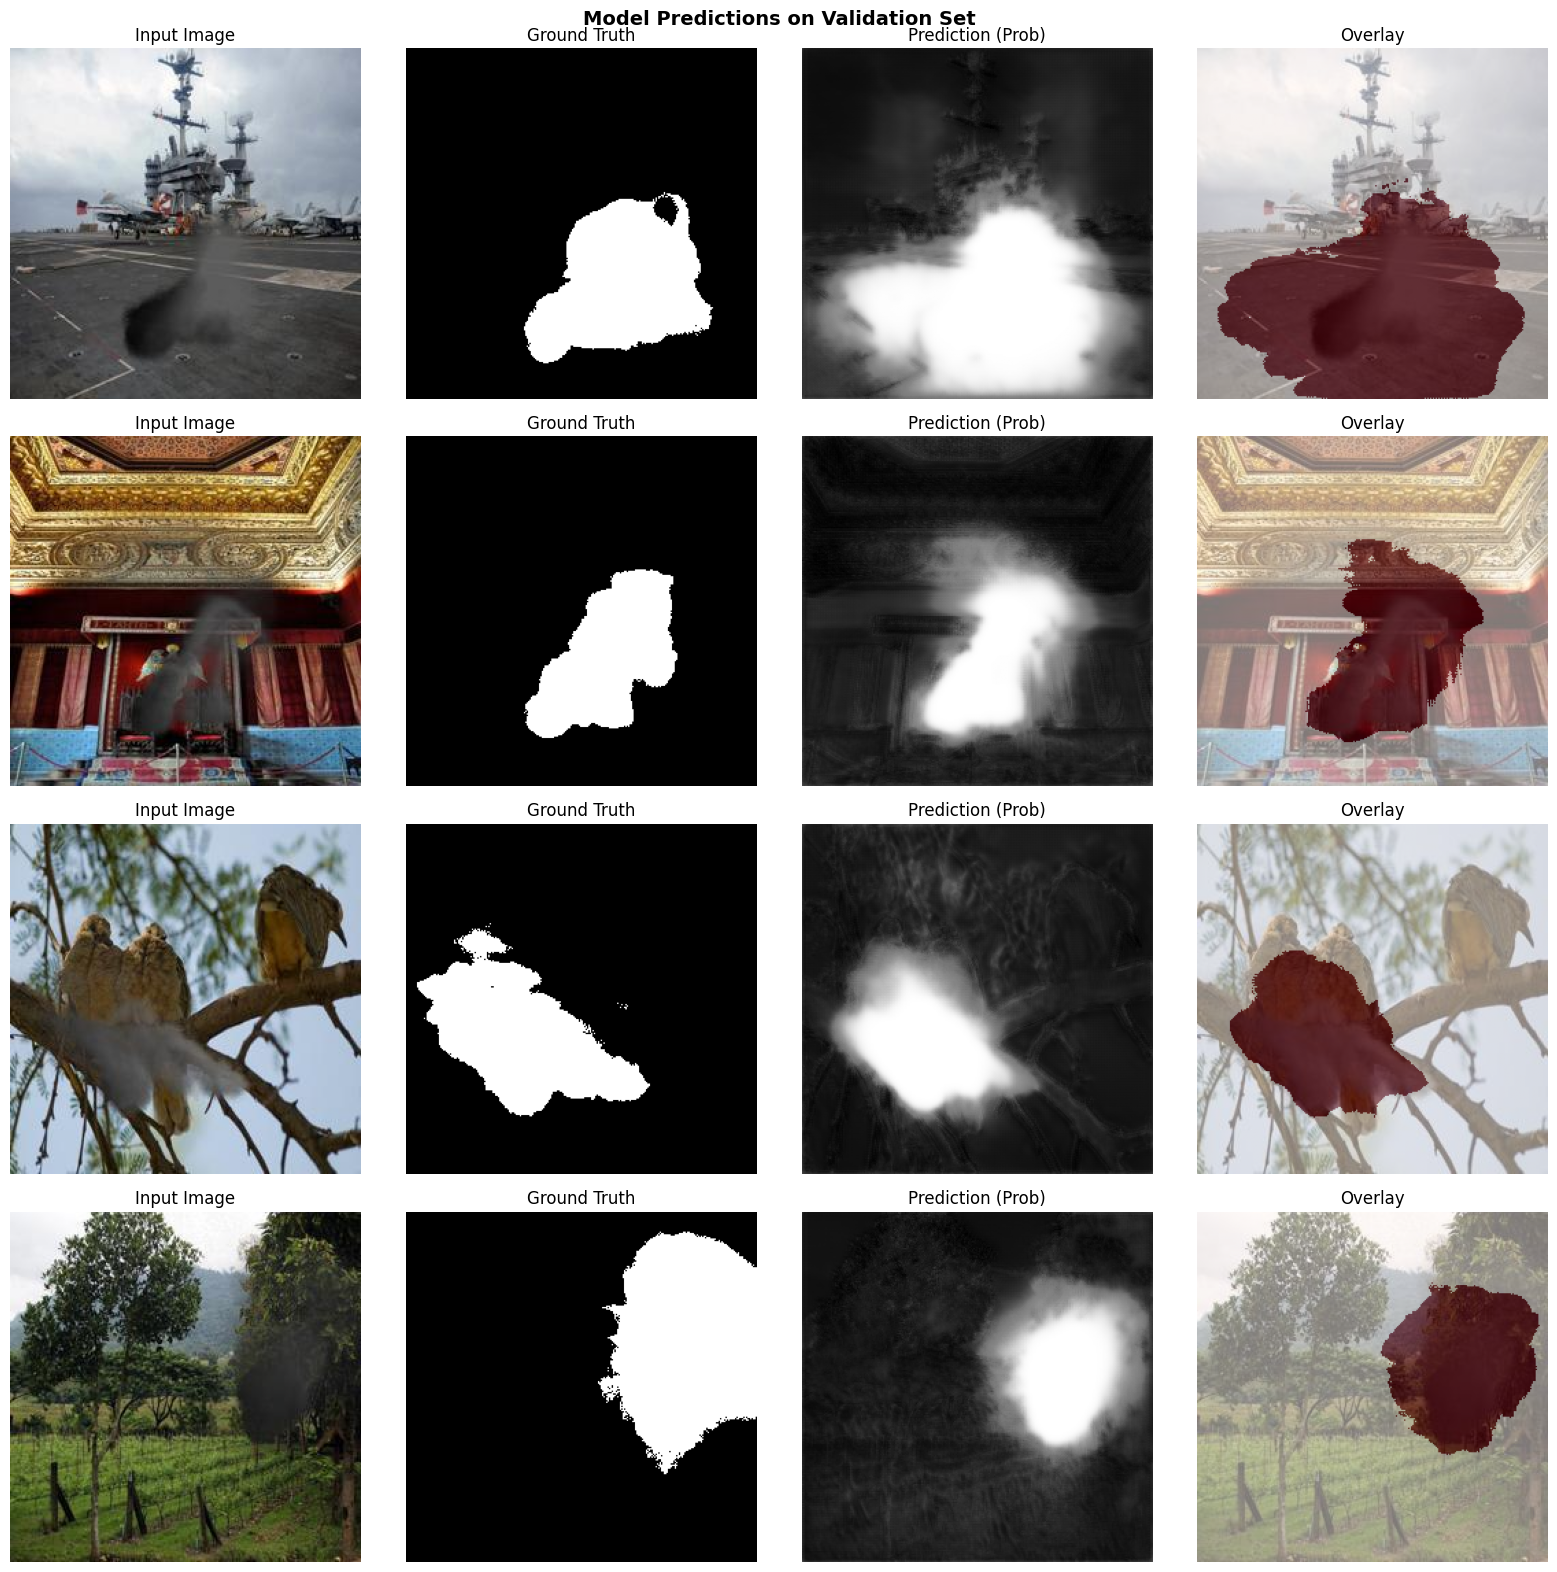

In [14]:
# Visualize Predictions
def visualize_predictions(model, dataloader, num_samples=4):
    """Display sample predictions"""
    model.eval()
    
    # Get a batch
    images, masks = next(iter(dataloader))
    images = images.to(device)
    
    with torch.no_grad():
        predictions = model(images)
        predictions = torch.sigmoid(predictions)  # Apply sigmoid for probabilities
    
    # Move to CPU for plotting
    images = images.cpu()
    masks = masks.cpu()
    predictions = predictions.cpu()
    
    # Denormalize images for display
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
    
    for i in range(min(num_samples, len(images))):
        # Denormalize image
        img = images[i] * std + mean
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        gt_mask = masks[i, 0].numpy()
        pred_mask = predictions[i, 0].numpy()
        pred_binary = (pred_mask > 0.5).astype(float)
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(gt_mask, cmap='gray')
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title("Prediction (Prob)")
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(img)
        axes[i, 3].imshow(pred_binary, alpha=0.5, cmap='Reds')
        axes[i, 3].set_title("Overlay")
        axes[i, 3].axis('off')
    
    plt.suptitle("Model Predictions on Validation Set", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_loader, num_samples=4)

In [ ]:
# Final Evaluation on Validation Set
model.eval()
total_iou = 0
total_dice = 0
num_batches = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        
        total_iou += calculate_iou(outputs, masks)
        total_dice += calculate_dice(outputs, masks)
        num_batches += 1

final_iou = total_iou / num_batches
final_dice = total_dice / num_batches

print("=" * 50)
print("Final Evaluation on Validation Set")
print("=" * 50)
print(f"IoU (Intersection over Union): {final_iou:.4f}")
print(f"Dice Coefficient: {final_dice:.4f}")
print("=" * 50)

Final Evaluation on Validation Set
IoU (Intersection over Union): 0.5685
Dice Coefficient: 0.7220


: 

In [11]:
# Save Model Checkpoint
save_path = "smoke5k_unet_model.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_ious': val_ious,
    'epoch': NUM_EPOCHS,
}, save_path)

print(f"Model saved to: {save_path}")
print(f"To load the model later:")
print(f"  checkpoint = torch.load('{save_path}')")
print(f"  model.load_state_dict(checkpoint['model_state_dict'])")

Model saved to: smoke5k_unet_model.pth
To load the model later:
  checkpoint = torch.load('smoke5k_unet_model.pth')
  model.load_state_dict(checkpoint['model_state_dict'])


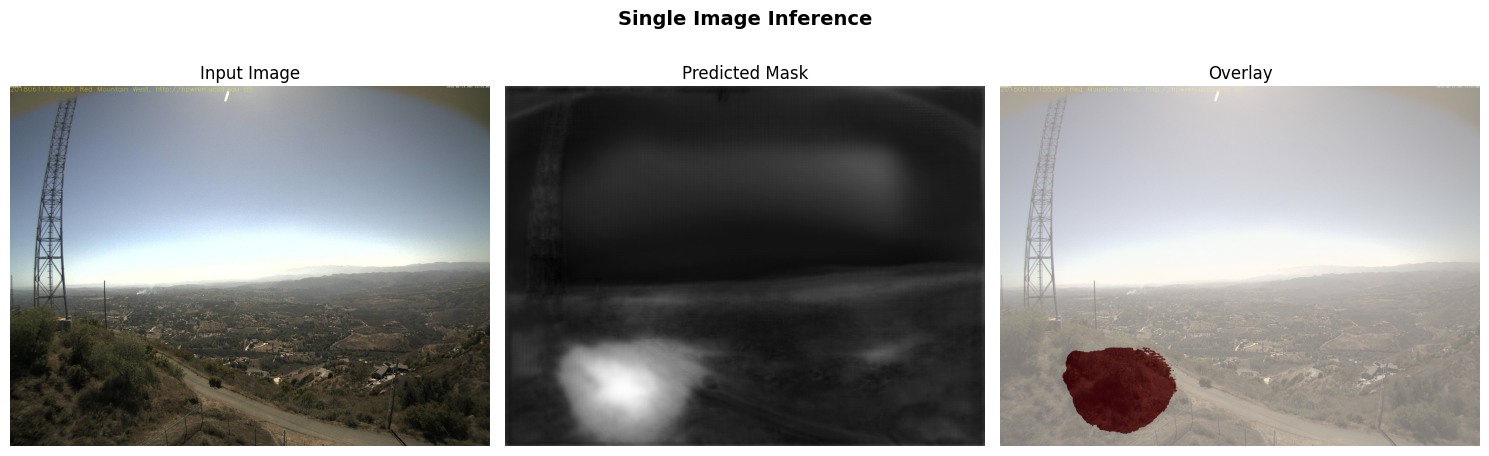

In [12]:
# Inference on a New Image
def predict_single_image(model, image_path, img_size=256):
    """Run inference on a single image"""
    model.eval()
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    original_size = image.size
    
    image_resized = image.resize((img_size, img_size), Image.BILINEAR)
    image_tensor = TF.to_tensor(image_resized)
    image_tensor = TF.normalize(image_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    image_tensor = image_tensor.unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        output = model(image_tensor)
        prediction = torch.sigmoid(output).squeeze().cpu().numpy()
    
    # Resize prediction back to original size
    pred_mask = Image.fromarray((prediction * 255).astype(np.uint8))
    pred_mask = pred_mask.resize(original_size, Image.BILINEAR)
    
    return image, np.array(pred_mask) / 255.0

# Test on a sample image
sample_image_path = os.path.join(smoke5k_img_path, all_images[0])
original_img, predicted_mask = predict_single_image(model, sample_image_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_img)
axes[0].set_title("Input Image")
axes[0].axis('off')

axes[1].imshow(predicted_mask, cmap='gray')
axes[1].set_title("Predicted Mask")
axes[1].axis('off')

axes[2].imshow(original_img)
axes[2].imshow(predicted_mask > 0.5, alpha=0.5, cmap='Reds')
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.suptitle("Single Image Inference", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()